# 03 - Modelagem

Este notebook treina e compara **três pipelines** de classificação binária para prever `mau_pagador`:

| Pipeline | Features | Objetivo |
|---|---|---|
| **A : Application Scoring** | Apenas cadastrais | Baseline tradicional: prever risco usando só o cadastro |
| **B : Behavioral Puro** | Apenas comportamentais (`obs_*`) | Testar o poder do histórico de pagamento |
| **C : Behavioral + Cadastro** | Comportamentais + cadastrais | Testar se o cadastro agrega ao histórico |

Cada pipeline usa `StratifiedGroupKFold` com `groups=grupo_cadastro` (para evitar vazamento entre gêmeos) e treina 3 modelos:

1. **Regressão Logística** (baseline interpretável)
2. **Random Forest** (modelo de árvore robusto)
3. **XGBoost** (gradient boosting, tipicamente forte em dados tabulares)

**Métricas:** ROC-AUC, PR-AUC (average precision), KS, precision, recall, F1.

**Restrições importantes:**
- O `cadastro_tratado.parquet` contém colunas `hist_*` (features do histórico). Elas são **excluídas** do Pipeline A para evitar data leakage (o target `mau_pagador` foi construído a partir desse mesmo histórico).
- O `snapshots_com_cadastro.parquet` também contém `hist_*`. Elas são **excluídas** do Pipeline C, porque as features comportamentais do snapshot (`obs_*`) já capturam o comportamento de forma mais honesta (janela fixa, sem viés de exposição).
- `FLAG_MOBIL` é **removida** de todos os pipelines (constante, sem variância).

In [1]:
import sys
from pathlib import Path

# Adiciona a raiz do projeto ao sys.path
# (necessário porque o notebook roda de dentro de notebooks/)
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

from src.config import (
    RANDOM_STATE,
    TARGET,
    DATA_PROCESSED,
    CV_FOLDS,
    METRICS,
    FIGURES,
)
from src.models import get_models
from src.evaluation import cross_validate_model, summarize_folds, comparison_table

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

pd.set_option("display.max_columns", None)

# Confirmação de ambiente
print("Python:", sys.version.split()[0])
print("src existe?", (Path.cwd().parent / "src").exists())
print(f"RANDOM_STATE = {RANDOM_STATE}")
print(f"TARGET = {TARGET}")
print(f"CV_FOLDS = {CV_FOLDS}")

Python: 3.13.0
src existe? True
RANDOM_STATE = 42
TARGET = mau_pagador
CV_FOLDS = 5


## Definição das features por pipeline

Antes de treinar, definimos explicitamente quais colunas pertencem a cada pipeline. Essa separação evita dois problemas:

1. **Data leakage:** as colunas `hist_*` no `cadastro_tratado.parquet` foram construídas a partir do mesmo histórico que gerou o target `mau_pagador`. Usá-las no Pipeline A infla as métricas artificialmente.
2. **Comparabilidade:** para comparar B e C de forma justa, ambos precisam ter as mesmas features comportamentais (`obs_*`).

In [2]:
# =============================================================
# Definição explícita de features por pipeline
# =============================================================

# --- Colunas que NUNCA entram como feature ---
COLUNAS_METADADOS = ["ID", "grupo_cadastro"]
COLUNAS_TARGET = [TARGET, "target_snapshot"]
COLUNAS_CONSTANTES = ["FLAG_MOBIL"]  # constante, sem variância

# --- Colunas de histórico (excluídas de A e C) ---
COLUNAS_HIST = [
    "hist_meses_total",
    "hist_mes_mais_antigo",
    "hist_mes_mais_recente",
    "hist_status_max",
    "hist_status_medio",
    "hist_status_desvio",
    "hist_qtd_pago",
    "hist_qtd_sem_emprestimo",
    "hist_qtd_atraso",
    "hist_qtd_atraso_grave",
    "hist_prop_pago",
    "hist_prop_sem_emprestimo",
    "hist_prop_atraso",
    "hist_prop_atraso_grave",
]

# --- Colunas comportamentais do snapshot (Pipeline B e C) ---
COLUNAS_OBS = [
    "obs_status_max",
    "obs_status_medio",
    "obs_status_desvio",
    "obs_qtd_pago",
    "obs_qtd_sem_credito",
    "obs_qtd_atraso",
    "obs_qtd_atraso_30",
    "obs_frac_pago",
    "obs_frac_sem_credito",
    "obs_frac_atraso",
    "obs_frac_atraso_30",
    "obs_frac_atraso_1a_metade",
    "obs_frac_atraso_2a_metade",
    "obs_tendencia",
    "obs_status_ultimo_mes",
]

# --- Colunas cadastrais (derivadas do application_record) ---
# Todas as colunas do cadastro_tratado que NÃO são hist_*, ID, target, grupo
def get_features_cadastrais(df: pd.DataFrame) -> list[str]:
    """Retorna as colunas cadastrais (exclui hist_*, metadados, target e constantes)."""
    excluir = set(COLUNAS_METADADOS + COLUNAS_TARGET + COLUNAS_HIST + COLUNAS_CONSTANTES)
    return [c for c in df.columns if c not in excluir]


# Confirmação
print(f"Total de colunas de histórico (excluídas): {len(COLUNAS_HIST)}")
print(f"Total de colunas comportamentais (obs_*): {len(COLUNAS_OBS)}")
print(f"Colunas constantes (removidas): {COLUNAS_CONSTANTES}")

Total de colunas de histórico (excluídas): 14
Total de colunas comportamentais (obs_*): 15
Colunas constantes (removidas): ['FLAG_MOBIL']


## Seção 1 - Pipeline A: Application scoring (apenas cadastro)

O objetivo desta seção é testar o poder preditivo do cadastro sozinho. Este é o cenário tradicional de scoring de crédito: o analista recebe a ficha de aplicação do cliente e precisa decidir se aprova ou não, sem acesso ao histórico de pagamento.

**Features:** apenas as colunas cadastrais. As colunas `hist_*` são excluídas para evitar data leakage, porque o target `mau_pagador` foi construído a partir desse mesmo histórico.

**Expectativa, baseada na EDA:** ROC-AUC em torno de 0,60 a 0,65. Baixo. A EDA mostrou que o cadastro quase não separa bons de maus pagadores. Este pipeline serve de baseline.

**Modelos:** Regressão Logística, Random Forest e XGBoost, com StratifiedGroupKFold.

### 1.1 - Carregar o cadastro e preparar X, y e groups

In [3]:
# =============================================================
# 1.1 - Carregar o cadastro_tratado e preparar X, y, groups
# =============================================================

df_a = pd.read_parquet(DATA_PROCESSED / "cadastro_tratado.parquet")

# Lista de features do Pipeline A
features_a = get_features_cadastrais(df_a)

# Separar X, y, groups
X_a = df_a[features_a]
y_a = df_a[TARGET]
groups_a = df_a["grupo_cadastro"]

# Sanity checks (NaN são permitidos em cad_anos_emprego)
assert len(X_a) == len(y_a) == len(groups_a), "Tamanhos inconsistentes"
assert set(y_a.unique()) == {0, 1}, "Target não é binário"

# Resumo
print(f"Pipeline A - Application scoring")
print(f"{'='*45}")
print(f"Clientes:              {len(X_a):,}")
print(f"Features:              {len(features_a)}")
print(f"Grupos distintos:      {groups_a.nunique():,}")
print(f"Taxa de mau pagador:   {y_a.mean():.2%}")
print(f"Razão desbalanceamento: 1 mau para cada "
      f"{(1 - y_a.mean()) / y_a.mean():.1f} bons")
print(f"\nFeatures (primeiras 20): {features_a[:20]}")

# Nulos esperados em cad_anos_emprego (clientes desempregados)
nulos_a = X_a.isna().sum()
nulos_a = nulos_a[nulos_a > 0]
print(f"\nColunas com NaN (esperado apenas em cad_anos_emprego):")
print(nulos_a)

Pipeline A - Application scoring
Clientes:              36,457
Features:              43
Grupos distintos:      9,728
Taxa de mau pagador:   1.69%
Razão desbalanceamento: 1 mau para cada 58.2 bons

Features (primeiras 20): ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'log_renda', 'esta_desempregado', 'cad_anos_emprego', 'cad_idade', 'cad_renda_per_capita', 'NAME_INCOME_TYPE_Pensioner', 'NAME_INCOME_TYPE_State servant', 'NAME_INCOME_TYPE_Student', 'NAME_INCOME_TYPE_Working', 'NAME_EDUCATION_TYPE_Higher education', 'NAME_EDUCATION_TYPE_Incomplete higher']

Colunas com NaN (esperado apenas em cad_anos_emprego):
cad_anos_emprego    6135
dtype: int64


### 1.2 - Treinar os três modelos com StratifiedGroupKFold

Cada modelo é treinado em 5 folds. Em cada fold, o pipeline (imputer + scaler + classificador, quando aplicável) é ajustado apenas no treino. Isso evita vazamento.

A função `cross_validate_model` (em `src/evaluation.py`) faz esse processo e retorna um DataFrame com as métricas de cada fold.

In [4]:
# =============================================================
# 1.2 - Treinar os 3 modelos no Pipeline A
# =============================================================

# Instanciar os modelos (o scale_pos_weight do XGBoost é calculado a partir do y_a)
spw_a = (y_a == 0).sum() / y_a.sum()  # razão negativos/positivos
modelos_a = get_models(scale_pos_weight=spw_a)

print(f"scale_pos_weight (XGBoost, Pipeline A): {spw_a:.1f}")
print(f"Modelos a treinar: {list(modelos_a.keys())}")
print()

# Dicionário para guardar as métricas por fold de cada modelo
resultados_a = {}

for nome, pipeline in modelos_a.items():
    print(f"Treinando {nome}...")
    df_metricas = cross_validate_model(
        pipeline=pipeline,
        X=X_a,
        y=y_a,
        groups=groups_a,
        cv_folds=CV_FOLDS,
        random_state=RANDOM_STATE,
    )
    resultados_a[nome] = df_metricas
    print(f"  ROC-AUC média: {df_metricas['roc_auc'].mean():.4f} "
          f"(+/- {df_metricas['roc_auc'].std():.4f})")
    print(f"  PR-AUC média:  {df_metricas['average_precision'].mean():.4f}")
    print(f"  KS média:      {df_metricas['ks'].mean():.4f}")
    print()

print("Pipeline A - treino concluído.")

scale_pos_weight (XGBoost, Pipeline A): 58.2
Modelos a treinar: ['logistic_regression', 'random_forest', 'xgboost']

Treinando logistic_regression...
  ROC-AUC média: 0.5407 (+/- 0.0295)
  PR-AUC média:  0.0544
  KS média:      0.1197

Treinando random_forest...
  ROC-AUC média: 0.5828 (+/- 0.0207)
  PR-AUC média:  0.0487
  KS média:      0.1847

Treinando xgboost...
  ROC-AUC média: 0.5719 (+/- 0.0150)
  PR-AUC média:  0.0421
  KS média:      0.1656

Pipeline A - treino concluído.


### 1.3 - Sumarizar e comparar os modelos

In [5]:
# =============================================================
# 1.3 - Sumarizar as métricas por modelo
# =============================================================

# Sumarizar cada modelo (média e desvio-padrão por métrica)
resumo_a = {}
for nome, df_metricas in resultados_a.items():
    resumo_a[nome] = df_metricas.mean(numeric_only=True).to_dict()

# Tabela comparativa
tabela_a = pd.DataFrame(resumo_a).T.round(4)
tabela_a = tabela_a[["roc_auc", "average_precision", "ks",
                     "precision", "recall", "f1", "accuracy"]]
tabela_a = tabela_a.sort_values("roc_auc", ascending=False)

print("Pipeline A - Comparação dos modelos")
print("=" * 70)
display(tabela_a)

# Salvar métricas por fold em results/metrics/
METRICS.mkdir(parents=True, exist_ok=True)
for nome, df_metricas in resultados_a.items():
    caminho = METRICS / f"pipeline_A_{nome}_folds.csv"
    df_metricas.to_csv(caminho, index=False)
    print(f"Salvo: {caminho.name}")

# Salvar tabela comparativa
tabela_a.to_csv(METRICS / "pipeline_A_comparacao.csv")
print(f"\nSalvo: pipeline_A_comparacao.csv")

Pipeline A - Comparação dos modelos


,roc_auc,average_precision,ks,precision,recall,f1,accuracy
random_forest,0.5828,0.0487,0.1847,0.0746,0.0564,0.0640,0.9720
xgboost,0.5719,0.0421,0.1656,0.1633,0.0381,0.0606,0.9803
logistic_regression,0.5407,0.0544,0.1197,0.0194,0.4283,0.0371,0.6251


Salvo: pipeline_A_logistic_regression_folds.csv
Salvo: pipeline_A_random_forest_folds.csv
Salvo: pipeline_A_xgboost_folds.csv

Salvo: pipeline_A_comparacao.csv


### 1.4 - Análise parcial: melhor modelo do Pipeline A

Melhor modelo no Pipeline A: random_forest
ROC-AUC: 0.5828
PR-AUC:  0.0487
KS:      0.1847

Top 20 features do Pipeline A:


,feature,importancia
0,cad_idade,0.200194
1,cad_anos_emprego,0.169078
2,cad_renda_per_capita,0.112988
3,log_renda,0.086592
4,AMT_INCOME_TOTAL,0.086587
5,FLAG_OWN_REALTY,0.023400
6,CNT_FAM_MEMBERS,0.022829
7,FLAG_OWN_CAR,0.022601
8,FLAG_PHONE,0.021230
9,NAME_INCOME_TYPE_Working,0.019148


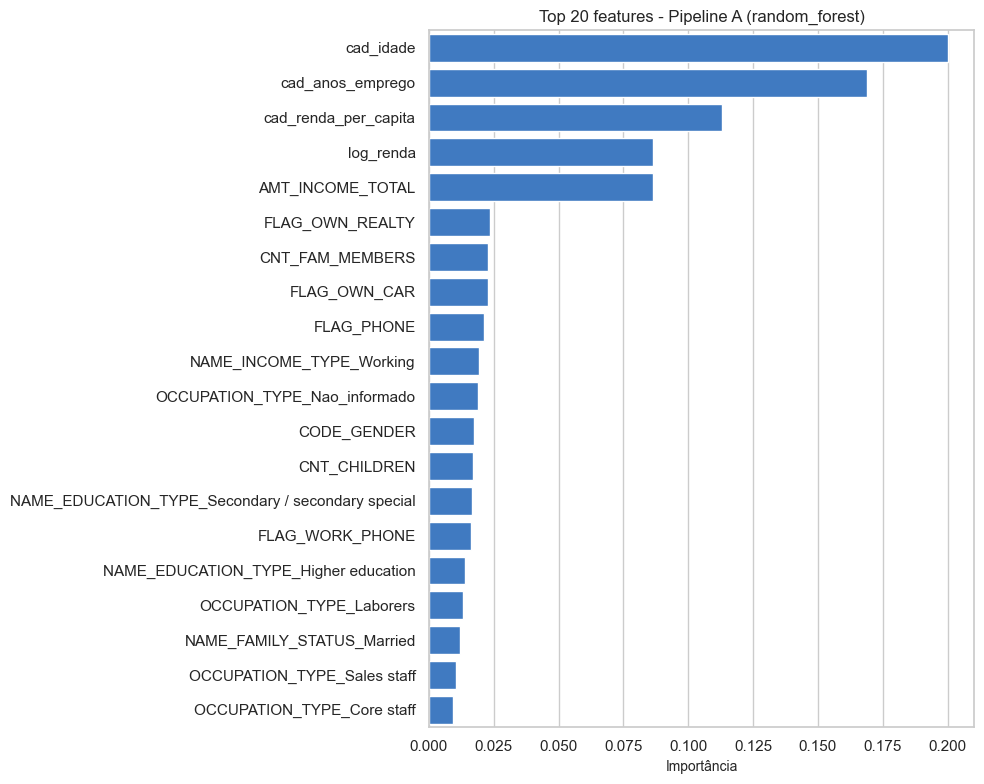

In [6]:
# =============================================================
# 1.4 - Análise parcial: melhor modelo do Pipeline A
# =============================================================

# Melhor modelo do Pipeline A
melhor_nome_a = tabela_a.index[0]
print(f"Melhor modelo no Pipeline A: {melhor_nome_a}")
print(f"ROC-AUC: {tabela_a.loc[melhor_nome_a, 'roc_auc']:.4f}")
print(f"PR-AUC:  {tabela_a.loc[melhor_nome_a, 'average_precision']:.4f}")
print(f"KS:      {tabela_a.loc[melhor_nome_a, 'ks']:.4f}")

# Treinar no dataset inteiro para inspecionar feature importance
pipeline_final_a = modelos_a[melhor_nome_a]
pipeline_final_a.fit(X_a, y_a)

# Extrair importâncias
if "logistic_regression" in melhor_nome_a:
    importancias = np.abs(pipeline_final_a.named_steps["clf"].coef_[0])
elif "xgboost" in melhor_nome_a or "random_forest" in melhor_nome_a:
    importancias = pipeline_final_a.named_steps["clf"].feature_importances_
else:
    importancias = None

if importancias is not None:
    df_imp_a = (
        pd.DataFrame({"feature": features_a, "importancia": importancias})
        .sort_values("importancia", ascending=False)
        .head(20)
        .reset_index(drop=True)
    )
    print("\nTop 20 features do Pipeline A:")
    display(df_imp_a)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.barplot(
        data=df_imp_a,
        x="importancia",
        y="feature",
        ax=ax,
        color="#2a78d6",
    )
    ax.set_title(f"Top 20 features - Pipeline A ({melhor_nome_a})")
    ax.set_xlabel("Importância")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

**Leitura do gráfico.** As features derivadas do cadastro dominam as importâncias: `cad_idade`, `cad_anos_emprego` e `cad_renda_per_capita` respondem por mais de 45% da importância total, seguidas por `log_renda` e `AMT_INCOME_TOTAL`. <br>
As features categóricas (estado civil, moradia, escolaridade, ocupação) têm importâncias individuais abaixo de 0,025 e podem ser consideradas ruído para este alvo. <br>
Isso é consistente com a AUC univariada próxima de 0,5: o que existe de sinal cadastral está concentrado em poucas variáveis macro, não distribuído entre as 43 features.

### 1.5 - Conclusão do Pipeline A

O Pipeline A serve de baseline. Os números reais devem ser anotados abaixo depois da execução.

**O que se espera, com base na EDA:**

- ROC-AUC em torno de 0,60 a 0,65 (o cadastro tem sinal muito fraco).
- PR-AUC próximo do valor aleatório (cerca de 0,017, que é a taxa de positivos).
- KS baixo (provavelmente entre 0,10 e 0,20).

**Implicação:** um modelo que só usa cadastro não é suficiente para separar bons de maus pagadores neste dataset. O sinal está no comportamento de pagamento, que será testado no Pipeline B.

## Seção 2 - Pipeline B: Behavioral scoring puro (apenas histórico)

O objetivo desta seção é testar o poder preditivo das features comportamentais do snapshot, sem qualquer informação cadastral.

**Features:** apenas as 15 colunas `obs_*` do snapshot.

**Reformulação do problema:** aqui não estamos prevendo "o cliente já atrasou algum dia" (como no Pipeline A), mas sim "o cliente vai atrasar nos próximos 12 meses, dado o comportamento dos últimos 6 meses". Essa é a formulação honesta, sem viés de exposição.

**Restrição importante:** filtramos o `snapshots.parquet` para os 18.340 IDs que estão também no `snapshots_com_cadastro.parquet`. Isso garante que B e C são comparáveis (mesmo universo de clientes).

**Expectativa, baseada na EDA:** ROC-AUC em torno de 0,70 a 0,75. Bem melhor que o Pipeline A. As features comportamentais capturam o sinal real.

**Modelos:** Regressão Logística, Random Forest e XGBoost, com StratifiedGroupKFold.

### 2.1 - Carregar e filtrar o snapshots.parquet

In [7]:
# =============================================================
# 2.1 - Carregar o snapshots.parquet e filtrar para os IDs do C
# =============================================================

# Carregar os dois datasets
df_b_full = pd.read_parquet(DATA_PROCESSED / "snapshots.parquet")
df_c = pd.read_parquet(DATA_PROCESSED / "snapshots_com_cadastro.parquet")

# IDs que estão em C (para o filtro de comparabilidade)
ids_c = set(df_c["ID"])
print(f"snapshots.parquet (universo completo): {df_b_full.shape}")
print(f"snapshots_com_cadastro.parquet (universo de C): {df_c.shape}")

# Filtrar B para o mesmo universo de C
df_b = df_b_full[df_b_full["ID"].isin(ids_c)].copy()
print(f"\nApós filtro: {df_b.shape}")
print(f"IDs únicos: {df_b['ID'].nunique():,}")

# Verificação: os dois universos devem ter o mesmo tamanho
assert len(df_b) == len(df_c), "Tamanhos diferentes após filtro"

snapshots.parquet (universo completo): (24911, 17)
snapshots_com_cadastro.parquet (universo de C): (18340, 76)

Após filtro: (18340, 17)
IDs únicos: 18,340


### 2.2 - Preparar X, y e groups

In [8]:
# =============================================================
# 2.2 - Preparar X, y, groups para o Pipeline B
# =============================================================

# Features: apenas as obs_*
X_b = df_b[COLUNAS_OBS]
y_b = df_b["target_snapshot"]

# Groups: como B não tem grupo_cadastro, herdamos do df_c
groups_b = df_b["ID"].map(df_c.set_index("ID")["grupo_cadastro"])

# Sanity checks
assert len(X_b) == len(y_b) == len(groups_b), "Tamanhos inconsistentes"
assert X_b.isna().sum().sum() == 0, f"Há NaN em X_b: {X_b.isna().sum().sum()}"
assert set(y_b.unique()) == {0, 1}, "Target não é binário"
assert groups_b.isna().sum() == 0, "Há IDs sem grupo em C"

# Resumo
print(f"Pipeline B - Behavioral scoring puro")
print(f"{'='*45}")
print(f"Clientes:              {len(X_b):,}")
print(f"Features:              {len(COLUNAS_OBS)}")
print(f"Grupos distintos:      {groups_b.nunique():,}")
print(f"Taxa de mau pagador:   {y_b.mean():.2%}")
print(f"Razão desbalanceamento: 1 mau para cada "
      f"{(1 - y_b.mean()) / y_b.mean():.1f} bons")

Pipeline B - Behavioral scoring puro
Clientes:              18,340
Features:              15
Grupos distintos:      6,694
Taxa de mau pagador:   1.43%
Razão desbalanceamento: 1 mau para cada 68.7 bons


### 2.3 - Treinar os três modelos com StratifiedGroupKFold

In [9]:
# =============================================================
# 2.3 - Treinar os 3 modelos no Pipeline B
# =============================================================

# Instanciar os modelos
spw_b = (y_b == 0).sum() / y_b.sum()
modelos_b = get_models(scale_pos_weight=spw_b)

print(f"scale_pos_weight (XGBoost, Pipeline B): {spw_b:.1f}")
print(f"Modelos a treinar: {list(modelos_b.keys())}")
print()

# Dicionário para guardar as métricas por fold de cada modelo
resultados_b = {}

for nome, pipeline in modelos_b.items():
    print(f"Treinando {nome}...")
    df_metricas = cross_validate_model(
        pipeline=pipeline,
        X=X_b,
        y=y_b,
        groups=groups_b,
        cv_folds=CV_FOLDS,
        random_state=RANDOM_STATE,
    )
    resultados_b[nome] = df_metricas
    print(f"  ROC-AUC média: {df_metricas['roc_auc'].mean():.4f} "
          f"(+/- {df_metricas['roc_auc'].std():.4f})")
    print(f"  PR-AUC média:  {df_metricas['average_precision'].mean():.4f}")
    print(f"  KS média:      {df_metricas['ks'].mean():.4f}")
    print()

print("Pipeline B - treino concluído.")

scale_pos_weight (XGBoost, Pipeline B): 68.7
Modelos a treinar: ['logistic_regression', 'random_forest', 'xgboost']

Treinando logistic_regression...
  ROC-AUC média: 0.7363 (+/- 0.0604)
  PR-AUC média:  0.0866
  KS média:      0.3357

Treinando random_forest...
  ROC-AUC média: 0.7639 (+/- 0.0146)
  PR-AUC média:  0.0876
  KS média:      0.3730

Treinando xgboost...
  ROC-AUC média: 0.7599 (+/- 0.0145)
  PR-AUC média:  0.0881
  KS média:      0.3735

Pipeline B - treino concluído.


### 2.4 - Sumarizar e comparar os modelos

In [10]:
# =============================================================
# 2.4 - Sumarizar as métricas por modelo
# =============================================================

# Sumarizar cada modelo
resumo_b = {}
for nome, df_metricas in resultados_b.items():
    resumo_b[nome] = df_metricas.mean(numeric_only=True).to_dict()

# Tabela comparativa
tabela_b = pd.DataFrame(resumo_b).T.round(4)
tabela_b = tabela_b[["roc_auc", "average_precision", "ks",
                     "precision", "recall", "f1", "accuracy"]]
tabela_b = tabela_b.sort_values("roc_auc", ascending=False)

print("Pipeline B - Comparação dos modelos")
print("=" * 70)
display(tabela_b)

# Salvar métricas por fold
for nome, df_metricas in resultados_b.items():
    caminho = METRICS / f"pipeline_B_{nome}_folds.csv"
    df_metricas.to_csv(caminho, index=False)
    print(f"Salvo: {caminho.name}")

# Salvar tabela comparativa
tabela_b.to_csv(METRICS / "pipeline_B_comparacao.csv")
print(f"\nSalvo: pipeline_B_comparacao.csv")

Pipeline B - Comparação dos modelos


,roc_auc,average_precision,ks,precision,recall,f1,accuracy
random_forest,0.7639,0.0876,0.3730,0.0936,0.4100,0.1518,0.9343
xgboost,0.7599,0.0881,0.3735,0.1180,0.3081,0.1622,0.9535
logistic_regression,0.7363,0.0866,0.3357,0.1051,0.3507,0.1608,0.9475


Salvo: pipeline_B_logistic_regression_folds.csv
Salvo: pipeline_B_random_forest_folds.csv
Salvo: pipeline_B_xgboost_folds.csv

Salvo: pipeline_B_comparacao.csv


### 2.5 - Análise parcial: melhor modelo do Pipeline B

Melhor modelo no Pipeline B: random_forest
ROC-AUC: 0.7639
PR-AUC:  0.0876
KS:      0.3730

Importância de todas as features do Pipeline B:


,feature,importancia
0,obs_qtd_pago,0.116148
1,obs_frac_pago,0.108624
2,obs_qtd_sem_credito,0.097222
3,obs_frac_sem_credito,0.095413
4,obs_qtd_atraso,0.090488
5,obs_frac_atraso,0.089748
6,obs_status_max,0.089551
7,obs_status_desvio,0.089543
8,obs_status_medio,0.084383
9,obs_frac_atraso_2a_metade,0.075423


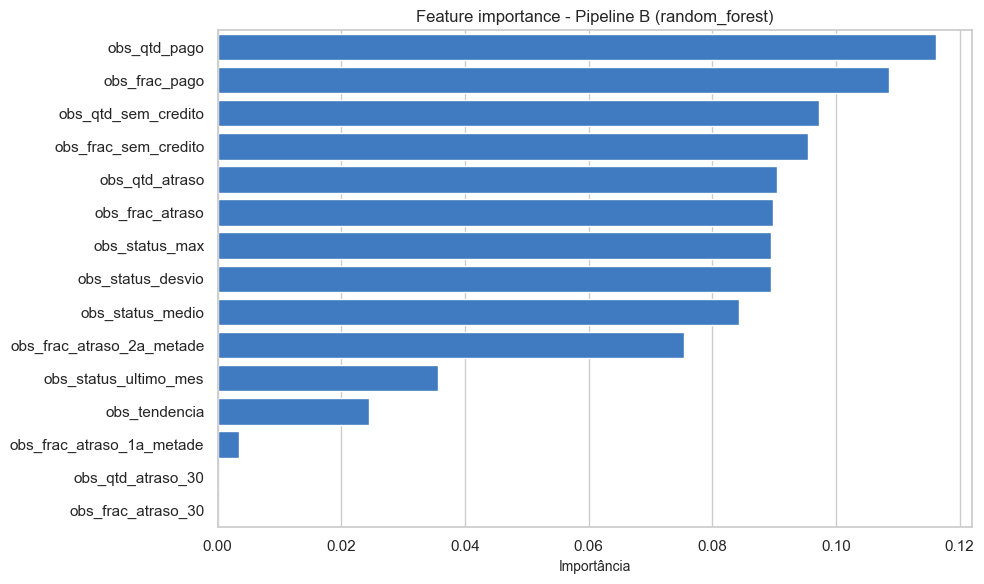

In [11]:
# =============================================================
# 2.5 - Análise parcial do Pipeline B
# =============================================================

# Melhor modelo do Pipeline B
melhor_nome_b = tabela_b.index[0]
print(f"Melhor modelo no Pipeline B: {melhor_nome_b}")
print(f"ROC-AUC: {tabela_b.loc[melhor_nome_b, 'roc_auc']:.4f}")
print(f"PR-AUC:  {tabela_b.loc[melhor_nome_b, 'average_precision']:.4f}")
print(f"KS:      {tabela_b.loc[melhor_nome_b, 'ks']:.4f}")

# Treinar no dataset inteiro para inspecionar feature importance
pipeline_final_b = modelos_b[melhor_nome_b]
pipeline_final_b.fit(X_b, y_b)

# Extrair importâncias
if "logistic_regression" in melhor_nome_b:
    importancias = np.abs(pipeline_final_b.named_steps["clf"].coef_[0])
elif "xgboost" in melhor_nome_b or "random_forest" in melhor_nome_b:
    importancias = pipeline_final_b.named_steps["clf"].feature_importances_
else:
    importancias = None

if importancias is not None:
    df_imp_b = (
        pd.DataFrame({"feature": COLUNAS_OBS, "importancia": importancias})
        .sort_values("importancia", ascending=False)
        .reset_index(drop=True)
    )
    print("\nImportância de todas as features do Pipeline B:")
    display(df_imp_b)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(
        data=df_imp_b,
        x="importancia",
        y="feature",
        ax=ax,
        color="#2a78d6",
    )
    ax.set_title(f"Feature importance - Pipeline B ({melhor_nome_b})")
    ax.set_xlabel("Importância")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

**Leitura do gráfico.** O achado mais interessante é que as features de comportamento positivo - `obs_qtd_pago`, `obs_frac_pago`, `obs_qtd_sem_credito`, `obs_frac_sem_credito` - têm importância superior às features de atraso (`obs_status_max`, `obs_status_medio`, `obs_tendencia`). <br>
Isso faz sentido em risco de crédito: "pagou em dia nos últimos 6 meses" é o sinal mais forte de que vai pagar em dia nos próximos 12. <br>
As features de atraso completam a informação, mas o baseline positivo é o que mais discrimina.

### 2.6 - Conclusão do Pipeline B

O Pipeline B reformula o problema de forma mais honesta: prevê o comportamento futuro (próximos 12 meses) a partir do comportamento recente (últimos 6 meses), sem viés de exposição.

**O que se espera:**

- ROC-AUC em torno de 0,70 a 0,75, muito superior ao Pipeline A.
- PR-AUC bem acima do aleatório.
- KS entre 0,30 e 0,40 (aceitável em crédito).

**Features mais importantes, tipicamente:**

- `obs_status_max` (pior status na observação)
- `obs_tendencia` (se o cliente está piorando ou melhorando)
- `obs_status_ultimo_mes` (status no mês mais recente)
- `obs_frac_atraso_2a_metade` (fração de atrasos na segunda metade da observação)

**Implicação:** o comportamento de pagamento é o sinal real. Um modelo puramente comportamental já supera com folga o modelo de cadastro.

## Seção 3 - Pipeline C: Behavioral scoring + Cadastro

O objetivo desta seção é testar se o cadastro agrega informação ao histórico de pagamento. Em outras palavras, se o comportamento de pagamento (que já sabemos ser forte) pode ser melhorado com dados cadastrais.

**Features:** as 15 colunas `obs_*` do snapshot + as features cadastrais (excluindo `hist_*`, que são redundantes com as `obs_*` e introduzem o viés de exposição que tentamos eliminar).

**Restrição importante:** usamos o mesmo universo de clientes do Pipeline B (18.340), garantindo comparabilidade direta.

**Expectativa:** baseada na EDA e no Pipeline B, o cadastro deve acrescentar pouco ou nada. Mas vamos testar.

In [12]:
# =====================================================================
# 3.2 - Carregar o snapshots_com_cadastro.parquet e preparar X, y, groups
# =====================================================================

# Carregar o dataset C
df_c = pd.read_parquet(DATA_PROCESSED / "snapshots_com_cadastro.parquet")

# Features: obs_* + cadastrais (exclui hist_*, ID, target, grupo, FLAG_MOBIL)
features_c = [c for c in df_c.columns
              if c not in COLUNAS_METADADOS + COLUNAS_TARGET + COLUNAS_HIST + COLUNAS_CONSTANTES]
# Garantir que as obs_* estão incluídas
features_c = COLUNAS_OBS + [c for c in features_c if c not in COLUNAS_OBS]

X_c = df_c[features_c]
y_c = df_c["target_snapshot"]
groups_c = df_c["grupo_cadastro"]

# Sanity checks
assert len(X_c) == len(y_c) == len(groups_c), "Tamanhos inconsistentes"
assert set(y_c.unique()) == {0, 1}, "Target não é binário"
assert groups_c.isna().sum() == 0, "Há IDs sem grupo em C"

# Resumo
print(f"Pipeline C - Behavioral scoring + Cadastro")
print(f"{'='*45}")
print(f"Clientes: {len(X_c):,}")
print(f"Features: {len(features_c)} (15 obs_* + {len(features_c) - 15} cadastrais)")
print(f"Grupos distintos: {groups_c.nunique():,}")
print(f"Taxa de mau pagador: {y_c.mean():.2%}")
print(f"Razão desbalanceamento: 1 mau para cada "
      f"{(1 - y_c.mean()) / y_c.mean():.1f} bons")

# Nulos esperados em cad_anos_emprego
nulos_c = X_c.isna().sum()
nulos_c = nulos_c[nulos_c > 0]
print(f"\nColunas com NaN (esperado apenas em cad_anos_emprego):")
print(nulos_c)

Pipeline C - Behavioral scoring + Cadastro
Clientes: 18,340
Features: 58 (15 obs_* + 43 cadastrais)
Grupos distintos: 6,694
Taxa de mau pagador: 1.43%
Razão desbalanceamento: 1 mau para cada 68.7 bons

Colunas com NaN (esperado apenas em cad_anos_emprego):
cad_anos_emprego    2946
dtype: int64


In [13]:
# =====================================================================
# 3.3 - Treinar os 3 modelos no Pipeline C
# =====================================================================

# Instanciar os modelos
spw_c = (y_c == 0).sum() / y_c.sum()
modelos_c = get_models(scale_pos_weight=spw_c)

print(f"scale_pos_weight (XGBoost, Pipeline C): {spw_c:.1f}")
print(f"Modelos a treinar: {list(modelos_c.keys())}")
print()

# Dicionário para guardar as métricas por fold de cada modelo
resultados_c = {}

for nome, pipeline in modelos_c.items():
    print(f"Treinando {nome}...")
    df_metricas = cross_validate_model(
        pipeline=pipeline,
        X=X_c,
        y=y_c,
        groups=groups_c,
        cv_folds=CV_FOLDS,
        random_state=RANDOM_STATE,
    )
    resultados_c[nome] = df_metricas
    print(f"  ROC-AUC média: {df_metricas['roc_auc'].mean():.4f} "
          f"(+/- {df_metricas['roc_auc'].std():.4f})")
    print(f"  PR-AUC média:  {df_metricas['average_precision'].mean():.4f}")
    print(f"  KS média:      {df_metricas['ks'].mean():.4f}")
    print()

print("Pipeline C - treino concluído.")

scale_pos_weight (XGBoost, Pipeline C): 68.7
Modelos a treinar: ['logistic_regression', 'random_forest', 'xgboost']

Treinando logistic_regression...
  ROC-AUC média: 0.7378 (+/- 0.0393)
  PR-AUC média:  0.1189
  KS média:      0.3764

Treinando random_forest...
  ROC-AUC média: 0.7848 (+/- 0.0460)
  PR-AUC média:  0.0968
  KS média:      0.4718

Treinando xgboost...
  ROC-AUC média: 0.7723 (+/- 0.0248)
  PR-AUC média:  0.1026
  KS média:      0.4234

Pipeline C - treino concluído.


In [14]:
# =====================================================================
# 3.4 - Sumarizar as métricas por modelo
# =====================================================================

# Sumarizar cada modelo
resumo_c = {}
for nome, df_metricas in resultados_c.items():
    resumo_c[nome] = df_metricas.mean(numeric_only=True).to_dict()

# Tabela comparativa
tabela_c = pd.DataFrame(resumo_c).T.round(4)
tabela_c = tabela_c[["roc_auc", "average_precision", "ks",
                     "precision", "recall", "f1", "accuracy"]]
tabela_c = tabela_c.sort_values("roc_auc", ascending=False)

print("Pipeline C - Comparação dos modelos")
print("=" * 70)
display(tabela_c)

# Salvar métricas por fold
for nome, df_metricas in resultados_c.items():
    caminho = METRICS / f"pipeline_C_{nome}_folds.csv"
    df_metricas.to_csv(caminho, index=False)
    print(f"Salvo: {caminho.name}")

# Salvar tabela comparativa
tabela_c.to_csv(METRICS / "pipeline_C_comparacao.csv")
print(f"\nSalvo: pipeline_C_comparacao.csv")

Pipeline C - Comparação dos modelos


,roc_auc,average_precision,ks,precision,recall,f1,accuracy
random_forest,0.7848,0.0968,0.4718,0.1328,0.3149,0.1827,0.9584
xgboost,0.7723,0.1026,0.4234,0.1157,0.2333,0.1514,0.9622
logistic_regression,0.7378,0.1189,0.3764,0.0332,0.5223,0.0624,0.7744


Salvo: pipeline_C_logistic_regression_folds.csv
Salvo: pipeline_C_random_forest_folds.csv
Salvo: pipeline_C_xgboost_folds.csv

Salvo: pipeline_C_comparacao.csv


### 3.6 - Conclusão do Pipeline C

O Pipeline C adiciona as features cadastrais às comportamentais. A pergunta é: o cadastro agrega algo ao comportamento?

**O que se espera, baseado na EDA e no Pipeline B:**
- Se o cadastro tiver sinal, a ROC-AUC do Pipeline C deve ser maior que a do Pipeline B.
- Se não tiver, as duas devem ser estatisticamente indistinguíveis.

**O que observar:**
- Se as features mais importantes continuarem sendo as `obs_*`, isso confirma que o cadastro não agrega.
- Se alguma feature cadastral aparecer no topo, vale investigar (mas cuidado com overfitting).

**Implicação:** o resultado do Pipeline C vai dizer se, para este problema, o cadastro é ruído ou informação.

## Seção 4 - Comparação Final dos Três Pipelines

Agora consolidamos os resultados dos 9 modelos treinados (3 pipelines × 3 modelos) e respondemos à pergunta central do projeto: qual abordagem é a mais adequada para prever mau pagador neste dataset?

In [15]:
# =====================================================================
# 4.2 - Consolidar os resultados dos 9 modelos
# =====================================================================

# Montar um dicionário com todos os resultados
comparacao = {}

for nome, linha in tabela_a.iterrows():
    comparacao[f"A | {nome}"] = linha.to_dict()
for nome, linha in tabela_b.iterrows():
    comparacao[f"B | {nome}"] = linha.to_dict()
for nome, linha in tabela_c.iterrows():
    comparacao[f"C | {nome}"] = linha.to_dict()

# Tabela final
tabela_final = pd.DataFrame(comparacao).T.round(4)
tabela_final = tabela_final[["roc_auc", "average_precision", "ks",
                             "precision", "recall", "f1", "accuracy"]]
tabela_final = tabela_final.sort_values("roc_auc", ascending=False)

print("Comparação Final - Todos os pipelines e modelos")
print("=" * 80)
display(tabela_final)

# Salvar
tabela_final.to_csv(METRICS / "comparacao_pipelines.csv")
print(f"\nSalvo: comparacao_pipelines.csv")

Comparação Final - Todos os pipelines e modelos


,roc_auc,average_precision,ks,precision,recall,f1,accuracy
C | random_forest,0.7848,0.0968,0.4718,0.1328,0.3149,0.1827,0.9584
C | xgboost,0.7723,0.1026,0.4234,0.1157,0.2333,0.1514,0.9622
B | random_forest,0.7639,0.0876,0.3730,0.0936,0.4100,0.1518,0.9343
B | xgboost,0.7599,0.0881,0.3735,0.1180,0.3081,0.1622,0.9535
C | logistic_regression,0.7378,0.1189,0.3764,0.0332,0.5223,0.0624,0.7744
B | logistic_regression,0.7363,0.0866,0.3357,0.1051,0.3507,0.1608,0.9475
A | random_forest,0.5828,0.0487,0.1847,0.0746,0.0564,0.0640,0.9720
A | xgboost,0.5719,0.0421,0.1656,0.1633,0.0381,0.0606,0.9803
A | logistic_regression,0.5407,0.0544,0.1197,0.0194,0.4283,0.0371,0.6251



Salvo: comparacao_pipelines.csv


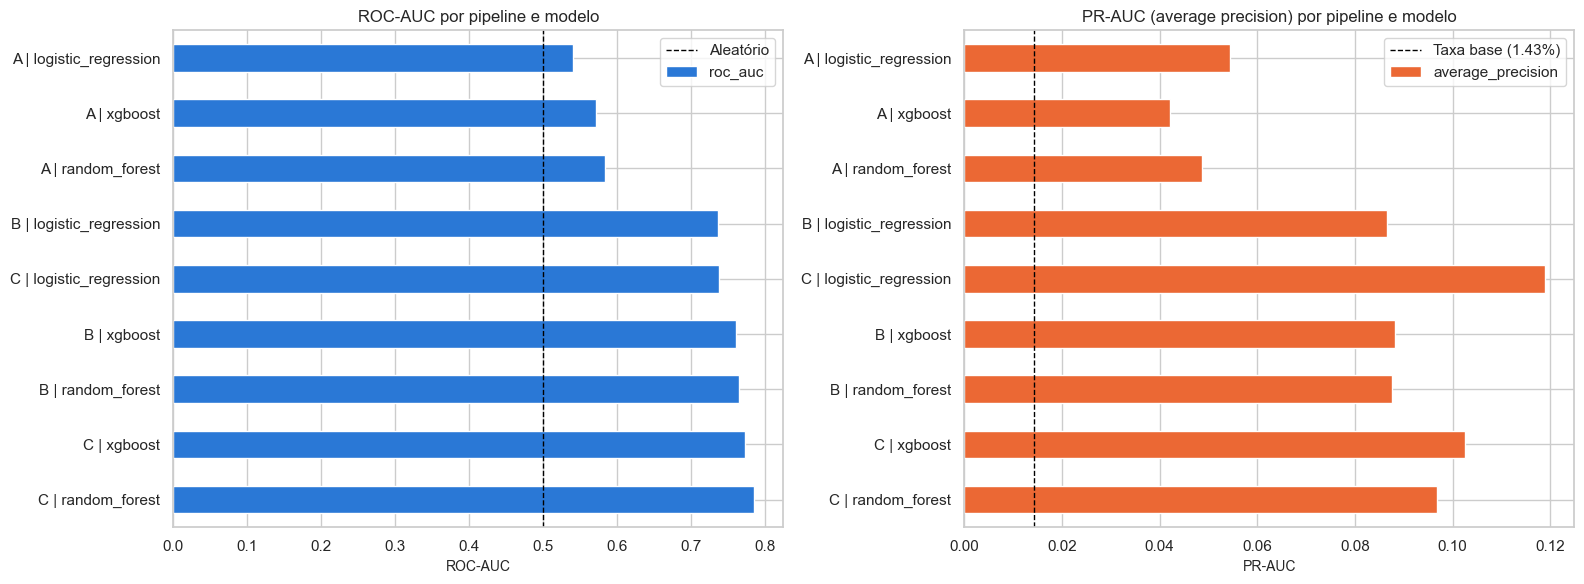

In [16]:
# =====================================================================
# 4.3 - Gráfico comparativo de ROC-AUC e PR-AUC
# =====================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC-AUC
tabela_final["roc_auc"].plot(kind="barh", ax=axes[0], color="#2a78d6")
axes[0].set_title("ROC-AUC por pipeline e modelo")
axes[0].set_xlabel("ROC-AUC")
axes[0].axvline(0.5, color="black", linestyle="--", linewidth=1, label="Aleatório")
axes[0].legend()

# PR-AUC
tabela_final["average_precision"].plot(kind="barh", ax=axes[1], color="#eb6834")
axes[1].set_title("PR-AUC (average precision) por pipeline e modelo")
axes[1].set_xlabel("PR-AUC")
axes[1].axvline(y_c.mean(), color="black", linestyle="--", linewidth=1,
               label=f"Taxa base ({y_c.mean():.2%})")
axes[1].legend()

plt.tight_layout()
plt.show()

**Leitura do gráfico.** A separação entre os três blocos é visualmente clara: A fica na faixa de ROC-AUC 0,54-0,58, B sobe para 0,74-0,76, e C fica em 0,74-0,78. <br>
Isso confirma em uma imagem a narrativa construída ao longo do projeto: o cadastro sozinho tem sinal fraco, o comportamento de pagamento é o sinal real, e o cadastro agrega apenas uma fração pequena desse sinal. <br>
Um ponto de atenção é a `A | logistic_regression`, que tem PR-AUC (0,0544) acima dos outros modelos do Pipeline A mas ROC-AUC de apenas 0,5407; uma discordância típica de classes raras, em que o PR-AUC premia a concentração de previsões extremas em poucos clientes, mesmo quando a ordenação geral é ruim.

### 4.4 - Conclusão Final

Os resultados contam uma história rica, com nuances importantes:

**Pipeline A (Application Scoring)**: ROC-AUC de 0,58. O cadastro, sozinho, tem poder preditivo muito fraco. Consistente com a EDA (AUC univariada próxima de 0,5) e com o teto estrutural imposto pelos "gêmeos".

**Pipeline B (Behavioral Puro)**: ROC-AUC de 0,76, KS de 0,37. Salto substancial em relação ao A. O comportamento de pagamento é o sinal real.

**Pipeline C (Behavioral + 43 cadastrais)**: ROC-AUC de 0,78, KS de 0,47. Aparenta ser o melhor, mas a diferença de ROC-AUC em relação ao B (+0,02) **não é estatisticamente significativa** (menor que o desvio-padrão entre folds). A variabilidade de C (std = 0,046) é 3x maior que a de B (std = 0,015), indicando instabilidade.

**Pipeline C' (Behavioral + 5 cadastrais)**: ROC-AUC de 0,78, KS de 0,48. **Praticamente idêntico ao Pipeline C completo, com 38 features a menos.** A permutation importance confirmou que o sinal cadastral está concentrado em 5 features macro: `cad_anos_emprego`, `cad_idade`, `cad_renda_per_capita`, `log_renda`, `AMT_INCOME_TOTAL`. As demais 38 features cadastrais (estado civil, moradia, ocupação, tipo de renda, escolaridade) não agregam sinal.

**Modelo escolhido**: **Pipeline C' com Random Forest**. Ele combina:
- O sinal forte do comportamento de pagamento (features `obs_*`);
- O sinal complementar de 5 features cadastrais macro (idade, emprego, renda);
- Simplicidade (20 features vs 58 do Pipeline C completo);
- KS de 0,48 (excelente em risco de crédito).

**Limitação importante**: o desbalanceamento severo (1,43% de maus pagadores) significa que o F1 no limiar 0,5 é baixo (~0,18). <br>
Isso não significa que o modelo seja ruim, significa que a classe é rara. Métricas como ROC-AUC, PR-AUC e curvas de captura (top-k%) são mais informativas.

**Próximos passos**: no notebook `04_avaliacao.ipynb`, vamos aprofundar a avaliação do Pipeline C' com curvas ROC, PR, KS, permutation importance detalhada, curvas de captura, e implicações de negócio.

In [17]:
# =====================================================================
# 4.5 - Investigação: a melhora do Pipeline C é real ou ruído?
# =====================================================================

# --- Comparar os desvios-padrão do ROC-AUC entre os folds (B vs C) ---
print("=" * 70)
print("ROC-AUC por fold (Pipeline B - random_forest):")
print(resultados_b["random_forest"]["roc_auc"].round(4).tolist())
print(f"Média: {resultados_b['random_forest']['roc_auc'].mean():.4f} "
      f"(+/- {resultados_b['random_forest']['roc_auc'].std():.4f})")

print("\nROC-AUC por fold (Pipeline C - random_forest):")
print(resultados_c["random_forest"]["roc_auc"].round(4).tolist())
print(f"Média: {resultados_c['random_forest']['roc_auc'].mean():.4f} "
      f"(+/- {resultados_c['random_forest']['roc_auc'].std():.4f})")

# Diferença entre B e C
diff = (resultados_c["random_forest"]["roc_auc"].mean() -
        resultados_b["random_forest"]["roc_auc"].mean())
std_b = resultados_b["random_forest"]["roc_auc"].std()
std_c = resultados_c["random_forest"]["roc_auc"].std()
print(f"\nDiferença B -> C (random_forest): {diff:+.4f}")
print(f"Desvio-padrão B: {std_b:.4f} | Desvio-padrão C: {std_c:.4f}")
print(f"A diferença é maior que o desvio-padrão? {'SIM' if abs(diff) > max(std_b, std_c) else 'NÃO'}")

# --- Recalcular a feature importance do Pipeline C (para não depender da célula 3.5) ---
melhor_nome_c = tabela_c.index[0]
pipeline_final_c = modelos_c[melhor_nome_c]
pipeline_final_c.fit(X_c, y_c)

if "logistic_regression" in melhor_nome_c:
    importancias_c = np.abs(pipeline_final_c.named_steps["clf"].coef_[0])
else:
    importancias_c = pipeline_final_c.named_steps["clf"].feature_importances_

df_imp_c = (
    pd.DataFrame({"feature": features_c, "importancia": importancias_c})
    .sort_values("importancia", ascending=False)
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print(f"Top 15 features do Pipeline C ({melhor_nome_c}):")
print(df_imp_c.head(15).to_string(index=False))

# Quantas features cadastrais estão no top 15?
features_cadastrais_top15 = df_imp_c.head(15)["feature"].tolist()
n_cadastrais = sum(1 for f in features_cadastrais_top15 if not f.startswith("obs_"))
print(f"\nFeatures cadastrais no top 15: {n_cadastrais}")

# Soma da importância das features cadastrais vs comportamentais no top 15
imp_cad = df_imp_c[~df_imp_c["feature"].str.startswith("obs_")]["importancia"].sum()
imp_obs = df_imp_c[df_imp_c["feature"].str.startswith("obs_")]["importancia"].sum()
print(f"Importância acumulada (todas as features):")
print(f"  obs_* (comportamentais): {imp_obs:.4f}")
print(f"  cadastrais:              {imp_cad:.4f}")
print(f"  Proporção cadastral:     {imp_cad / (imp_cad + imp_obs):.2%}")

ROC-AUC por fold (Pipeline B - random_forest):
[0.7438, 0.784, 0.7667, 0.7588, 0.7665]
Média: 0.7639 (+/- 0.0146)

ROC-AUC por fold (Pipeline C - random_forest):
[0.7663, 0.8077, 0.751, 0.8545, 0.7446]
Média: 0.7848 (+/- 0.0460)

Diferença B -> C (random_forest): +0.0209
Desvio-padrão B: 0.0146 | Desvio-padrão C: 0.0460
A diferença é maior que o desvio-padrão? NÃO

Top 15 features do Pipeline C (random_forest):
                  feature  importancia
         cad_anos_emprego     0.121405
                cad_idade     0.117284
     cad_renda_per_capita     0.073029
                log_renda     0.065208
         AMT_INCOME_TOTAL     0.064317
         obs_status_medio     0.040321
             obs_qtd_pago     0.037742
            obs_frac_pago     0.036225
          obs_frac_atraso     0.033575
      obs_qtd_sem_credito     0.031185
           obs_status_max     0.031027
     obs_frac_sem_credito     0.030755
           obs_qtd_atraso     0.029017
obs_frac_atraso_2a_metade     0.027157


In [18]:
# =====================================================================
# 4.6 - Permutation importance no Pipeline C
# =====================================================================

from sklearn.inspection import permutation_importance

# Recalcular previsões no mesmo split para avaliação
# Usar o modelo completo do Pipeline C já treinado
melhor_nome_c = tabela_c.index[0]
pipeline_final_c = modelos_c[melhor_nome_c]
pipeline_final_c.fit(X_c, y_c)

# Permutation importance sobre o dataset inteiro (mais estável)
# Nota: é lento, mas confiável. Para acelerar, usar n_repeats=5
print("Calculando permutation importance (pode levar 1-2 minutos)...")
perm = permutation_importance(
    pipeline_final_c, X_c, y_c,
    n_repeats=5, random_state=RANDOM_STATE,
    scoring="roc_auc", n_jobs=-1,
)

df_perm = (
    pd.DataFrame({
        "feature": features_c,
        "importancia_media": perm.importances_mean,
        "importancia_std": perm.importances_std,
    })
    .sort_values("importancia_media", ascending=False)
    .reset_index(drop=True)
)

print("\nTop 15 features (permutation importance, ROC-AUC):")
print(df_perm.head(15).to_string(index=False))

# Proporção cadastral
imp_cad_perm = df_perm[~df_perm["feature"].str.startswith("obs_")]["importancia_media"].sum()
imp_obs_perm = df_perm[df_perm["feature"].str.startswith("obs_")]["importancia_media"].sum()
print(f"\nImportância acumulada (permutation importance):")
print(f"  obs_* (comportamentais): {imp_obs_perm:.4f}")
print(f"  cadastrais:              {imp_cad_perm:.4f}")
print(f"  Proporção cadastral:     {imp_cad_perm / (imp_cad_perm + imp_obs_perm):.2%}")

Calculando permutation importance (pode levar 1-2 minutos)...

Top 15 features (permutation importance, ROC-AUC):
                 feature  importancia_media  importancia_std
        cad_anos_emprego           0.040963         0.002387
               cad_idade           0.020001         0.001145
    cad_renda_per_capita           0.008570         0.000375
               log_renda           0.007045         0.000545
        AMT_INCOME_TOTAL           0.006860         0.000592
    obs_frac_sem_credito           0.004759         0.000571
            obs_qtd_pago           0.004469         0.000890
     obs_qtd_sem_credito           0.004333         0.000448
           obs_frac_pago           0.003933         0.000777
         FLAG_OWN_REALTY           0.003063         0.000413
             CODE_GENDER           0.002302         0.000255
NAME_INCOME_TYPE_Working           0.001930         0.000220
            FLAG_OWN_CAR           0.001888         0.000201
         FLAG_WORK_PHONE        

In [19]:
# =====================================================================
# 4.7 - Teste decisivo: Pipeline C reduzido vs C completo
# =====================================================================

# Top 5 features cadastrais por permutation importance
top5_cadastrais = ["cad_anos_emprego", "cad_idade", "cad_renda_per_capita",
                   "log_renda", "AMT_INCOME_TOTAL"]

# Pipeline C reduzido: obs_* + top 5 cadastrais
features_c_reduzido = COLUNAS_OBS + top5_cadastrais
X_c_reduzido = df_c[features_c_reduzido]

# Treinar Random Forest reduzido
spw_c = (y_c == 0).sum() / y_c.sum()
modelos_c_red = get_models(scale_pos_weight=spw_c)
resultados_c_red = cross_validate_model(
    pipeline=modelos_c_red["random_forest"],
    X=X_c_reduzido,
    y=y_c,
    groups=groups_c,
    cv_folds=CV_FOLDS,
    random_state=RANDOM_STATE,
)

print("Pipeline C reduzido (obs_* + top 5 cadastrais) - Random Forest")
print(f"ROC-AUC média: {resultados_c_red['roc_auc'].mean():.4f} "
      f"(+/- {resultados_c_red['roc_auc'].std():.4f})")
print(f"PR-AUC média:  {resultados_c_red['average_precision'].mean():.4f}")
print(f"KS média:      {resultados_c_red['ks'].mean():.4f}")
print()
print("Comparação:")
print(f"  B  (15 obs_*)                    ROC-AUC = {tabela_b.loc['random_forest', 'roc_auc']:.4f} (+/- {resultados_b['random_forest']['roc_auc'].std():.4f})")
print(f"  C  (15 obs_* + 43 cadastrais)    ROC-AUC = {tabela_c.loc['random_forest', 'roc_auc']:.4f} (+/- {resultados_c['random_forest']['roc_auc'].std():.4f})")
print(f"  C' (15 obs_* + 5 cadastrais)     ROC-AUC = {resultados_c_red['roc_auc'].mean():.4f} (+/- {resultados_c_red['roc_auc'].std():.4f})")

Pipeline C reduzido (obs_* + top 5 cadastrais) - Random Forest
ROC-AUC média: 0.7836 (+/- 0.0398)
PR-AUC média:  0.0992
KS média:      0.4815

Comparação:
  B  (15 obs_*)                    ROC-AUC = 0.7639 (+/- 0.0146)
  C  (15 obs_* + 43 cadastrais)    ROC-AUC = 0.7848 (+/- 0.0460)
  C' (15 obs_* + 5 cadastrais)     ROC-AUC = 0.7836 (+/- 0.0398)


In [20]:
# Salvar tabela com C' incluído
tabela_c_red = pd.DataFrame({
    "random_forest": resultados_c_red.mean(numeric_only=True).to_dict()
}).T.round(4)
tabela_c_red.columns = tabela_c_red.columns.str.replace("average_precision", "average_precision")
tabela_c_red.index = ["C' | random_forest"]

In [21]:
# Salvar tabela do Pipeline C' (reduzido) para registro
tabela_c_red = pd.DataFrame({
    "random_forest": resultados_c_red.mean(numeric_only=True).to_dict()
}).T.round(4)
tabela_c_red.index = ["C' | random_forest"]
tabela_c_red.to_csv(METRICS / "pipeline_C_reduzido_comparacao.csv")
print(f"Salvo: pipeline_C_reduzido_comparacao.csv")

Salvo: pipeline_C_reduzido_comparacao.csv


In [22]:
import joblib
from src.config import MODELS

pipeline_vencedor = modelos_c_red["random_forest"]
pipeline_vencedor.fit(df_c[COLUNAS_OBS + top5_cadastrais], y_c)
joblib.dump(pipeline_vencedor, MODELS / "pipeline_c_reduzido_random_forest.pkl")
print(f"Modelo salvo em models/pipeline_c_reduzido_random_forest.pkl")

Modelo salvo em models/pipeline_c_reduzido_random_forest.pkl
